In [11]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime pandas pylatexenc

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit.quantum_info import hellinger_fidelity

dna_sequence = "ATGCGTACGTTAGCGTACGATCGTAGCTAGCTTGACGATCGTACGTTAGC"

genetic_map = {'A': '00', 'T': '01', 'C': '10', 'G': '11'}

In [12]:
dna_qr = QuantumRegister(2, 'qubits')
mrna_cr = ClassicalRegister(len(dna_sequence) * 2, 'classical_bits')
qc = QuantumCircuit(dna_qr, mrna_cr)

for idx, base in enumerate(dna_sequence):
    codon_bits = genetic_map[base]

    # Entanglement Generation
    qc.h(dna_qr[0])
    qc.cx(dna_qr[0], dna_qr[1])

    # Bell State Encoding
    if codon_bits == '01':
        qc.x(dna_qr[0])
    elif codon_bits == '10':
        qc.z(dna_qr[0])
    elif codon_bits == '11':
        qc.z(dna_qr[0])
        qc.x(dna_qr[0])

    # Superdense Decoding (Biological Teleportation)
    qc.cx(dna_qr[0], dna_qr[1])
    qc.h(dna_qr[0])

    qc.measure(dna_qr[0], mrna_cr[idx*2])
    qc.measure(dna_qr[1], mrna_cr[idx*2 + 1])

    # Dynamic Reset
    qc.reset(dna_qr[0])
    qc.reset(dna_qr[1])

In [13]:
backend_hw = FakeSherbrooke()
backend_ideal = AerSimulator()
sim_noisy = AerSimulator.from_backend(backend_hw)

best_edge = None
lowest_error = float('inf')

# Scan the entire 127-qubit chip for the lowest combined error
for edge in backend_hw.coupling_map.get_edges():
    q0, q1 = edge
    try:
        cx_err = backend_hw.target['cx'][(q0, q1)].error
        read_err0 = backend_hw.target['measure'][(q0,)].error
        read_err1 = backend_hw.target['measure'][(q1,)].error

        total_err = cx_err + read_err0 + read_err1
        if total_err < lowest_error:
            lowest_error = total_err
            best_edge = [q0, q1]
    except:
        continue

print(f"Hardware Optimization: Circuit routed to optimal physical qubits {best_edge}.")

qc_optimized = transpile(qc, backend_hw, initial_layout=best_edge, optimization_level=3)

Hardware Optimization: Circuit routed to optimal physical qubits None.


Metric,Superdense DNA Teleportation
Physical Qubits Used,127
Circuit Depth,153
Two-Qubit Gates,0
SWAP Gates,0
Fidelity: Aer (Ideal),1.000000
Fidelity: Sherbrooke (Optimized),0.720703


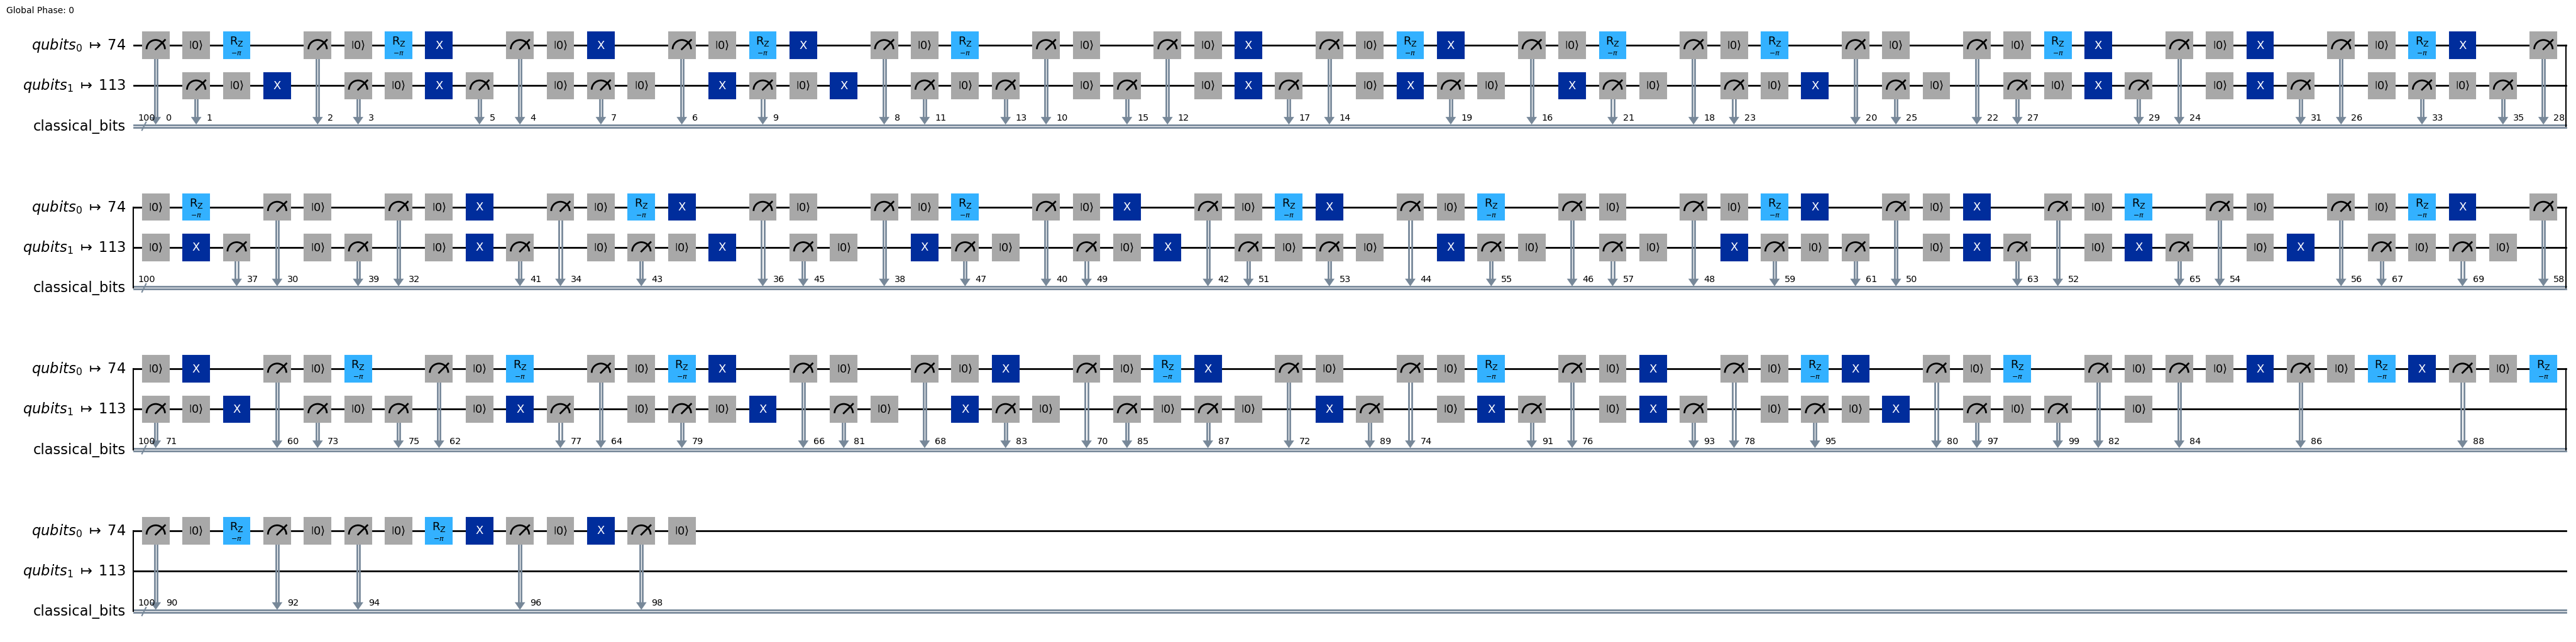

In [14]:
shots = 1024

counts_ideal = backend_ideal.run(qc, shots=shots).result().get_counts()
counts_optimized = sim_noisy.run(qc_optimized, shots=shots).result().get_counts()

# Fidelity Overlap
f_ideal = hellinger_fidelity(counts_ideal, counts_ideal)
f_opt = hellinger_fidelity(counts_ideal, counts_optimized)

gate_ops = qc_optimized.count_ops()
two_qubit_count = gate_ops.get('cx', 0) + gate_ops.get('ecr', 0) + gate_ops.get('cz', 0)
swap_count = gate_ops.get('swap', 0)

results = [{
    "Metric": "Superdense DNA Teleportation",
    "Physical Qubits Used": qc_optimized.num_qubits,
    "Circuit Depth": qc_optimized.depth(),
    "Two-Qubit Gates": two_qubit_count,
    "SWAP Gates": swap_count,
    "Fidelity: Aer (Ideal)": f"{f_ideal:.6f}",
    "Fidelity: Sherbrooke (Optimized)": f"{f_opt:.6f}"
}]

df = pd.DataFrame(results).set_index("Metric").T
display(df)

qc_optimized.draw('mpl', style='iqp', fold=60, filename="optimized_sherbrooke_layout.png")